In [31]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import sklearn
from sklearn.preprocessing import StandardScaler

In [32]:
batsman_df=pd.read_csv("Cricket (1).csv", sep=",",encoding="ISO-8859-1",header=0)

In [33]:
batsman_df.head()

,Player,Span,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0
0,SR Tendulkar (INDIA),1989-2012,463,452,41,18426,200*,44.83,21367,86.23,49,96,20
1,KC Sangakkara (Asia/ICC/SL),2000-2015,404,380,41,14234,169,41.98,18048,78.86,25,93,15
2,RT Ponting (AUS/ICC),1995-2012,375,365,39,13704,164,42.03,17046,80.39,30,82,20
3,ST Jayasuriya (Asia/SL),1989-2011,445,433,18,13430,189,32.36,14725,91.20,28,68,34
4,DPMD Jayawardene (Asia/SL),1998-2015,448,418,39,12650,144,33.37,16020,78.96,19,77,28


In [34]:
batsman_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79 entries, 0 to 78
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  79 non-null     object 
 1   Span    79 non-null     object 
 2   Mat     79 non-null     int64  
 3   Inns    79 non-null     int64  
 4   NO      79 non-null     int64  
 5   Runs    79 non-null     int64  
 6   HS      79 non-null     object 
 7   Ave     79 non-null     float64
 8   BF      79 non-null     int64  
 9   SR      79 non-null     float64
 10  100     79 non-null     int64  
 11  50      79 non-null     int64  
 12  0       79 non-null     int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 8.2+ KB


In [35]:
batsman_df.shape

(79, 13)

In [36]:
batsman_df_up=batsman_df[['Ave','SR']]

In [37]:
batsman_df_up

,Ave,SR
0,44.83,86.23
1,41.98,78.86
2,42.03,80.39
3,32.36,91.20
4,33.37,78.96
...,...,...
74,45.03,64.92
75,43.40,73.75
76,35.36,76.98
77,39.75,92.44


In [38]:
scaler=StandardScaler()

In [39]:
batsman_df_scaled=scaler.fit_transform(batsman_df_up)

In [40]:
batsman_df_scaled

array([[ 1.07229395,  0.70315153],
       [ 0.58772461, -0.0441395 ],
       [ 0.59622582,  0.1109969 ],
       [-1.04790945,  1.20709133],
       [-0.87618487, -0.03399986],
       [ 0.16946476, -0.51259058],
       [ 0.99238251, -0.64947564],
       [ 0.42450125, -0.56734461],
       [ 0.108256  , -0.8167796 ],
       [ 0.33268811,  0.02176813],
       [ 0.12695867,  0.70315153],
       [ 0.54181804, -0.42538973],
       [-0.44772356,  1.78910632],
       [ 2.17575185,  0.95258652],
       [-0.2725985 , -0.53489778],
       [ 2.5549061 ,  2.1247282 ],
       [-0.61604765,  0.1860302 ],
       [-0.20288853,  0.58958763],
       [ 0.11675721,  0.13938788],
       [ 0.52311536, -0.86747777],
       [-0.3355075 ,  0.84916225],
       [ 0.48400977, -1.64315977],
       [-0.16208269, -1.17369472],
       [ 0.14056062, -0.24287632],
       [-0.590544  ,  2.53842527],
       [ 2.62121559,  1.1857981 ],
       [-0.40691772,  0.4020044 ],
       [-2.5424233 ,  3.82311689],
       [-1.04110847,

In [41]:
batsman_df_scaled=pd.DataFrame(batsman_df_scaled)

In [42]:
batsman_df_scaled

,0,1
0,1.072294,0.703152
1,0.587725,-0.044139
2,0.596226,0.110997
3,-1.047909,1.207091
4,-0.876185,-0.034000
...,...,...
74,1.106299,-1.457604
75,0.829159,-0.562275
76,-0.537836,-0.234765
77,0.208570,1.332823


In [43]:
batsman_df_scaled.columns=['Ave','SR']

In [44]:
batsman_df_scaled

,Ave,SR
0,1.072294,0.703152
1,0.587725,-0.044139
2,0.596226,0.110997
3,-1.047909,1.207091
4,-0.876185,-0.034000
...,...,...
74,1.106299,-1.457604
75,0.829159,-0.562275
76,-0.537836,-0.234765
77,0.208570,1.332823


In [45]:
from sklearn.cluster import KMeans

In [46]:
kmean=KMeans(n_clusters=4,max_iter=50,random_state=100)

In [47]:
help(kmean)

Help on KMeans in module sklearn.cluster._kmeans object:

class KMeans(_BaseKMeans)
 |  KMeans(
 |      n_clusters=8,
 |      *,
 |      init='k-means++',
 |      n_init='auto',
 |      max_iter=300,
 |      tol=0.0001,
 |      verbose=0,
 |      random_state=None,
 |      copy_x=True,
 |      algorithm='lloyd'
 |  )
 |
 |  K-Means clustering.
 |
 |  Read more in the :ref:`User Guide <k_means>`.
 |
 |  Parameters
 |  ----------
 |
 |  n_clusters : int, default=8
 |      The number of clusters to form as well as the number of
 |      centroids to generate.
 |
 |      For an example of how to choose an optimal value for `n_clusters` refer to
 |      :ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.
 |
 |  init : {'k-means++', 'random'}, callable or array-like of shape             (n_clusters, n_features), default='k-means++'
 |      Method for initialization:
 |
 |      * 'k-means++' : selects initial cluster centroids using sampling             based on an empiri

In [48]:
kmean.fit(batsman_df_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",50
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",100
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [50]:
kmean.labels_

array([2, 2, 2, 3, 1, 2, 2, 2, 1, 2, 2, 2, 3, 0, 1, 0, 1, 2, 2, 2, 2, 1,
       1, 2, 3, 0, 2, 3, 1, 2, 1, 1, 2, 1, 0, 1, 1, 2, 0, 2, 1, 1, 0, 1,
       1, 1, 2, 1, 1, 2, 3, 2, 1, 1, 1, 1, 2, 2, 1, 2, 1, 3, 2, 2, 0, 2,
       2, 1, 2, 1, 2, 1, 1, 1, 2, 2, 1, 2, 1], dtype=int32)

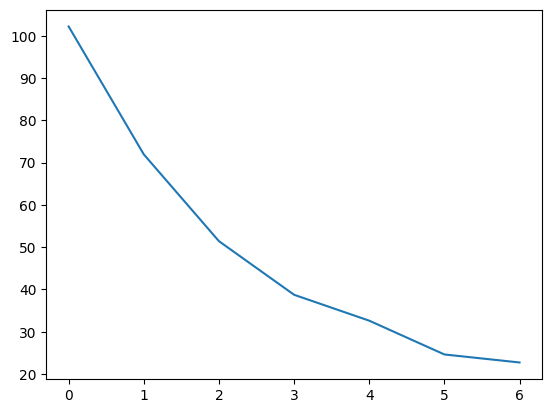

In [51]:
range_of_clusters=[2,3,4,5,6,7,8]
ssd=[]

for  num_clusters in range_of_clusters:
    kmean=KMeans(n_clusters=num_clusters,max_iter=50,random_state=100)
    kmean.fit(batsman_df_scaled)

    ssd.append(kmean.inertia_)

#sum of squared distances  for each n_clusters amd plotting it

plt.plot(ssd)

In [52]:
#silhoutte analysis
from sklearn.metrics import silhouette_score
for num_clusters in range_of_clusters:
    #intialising kmeans
    kmean=KMeans(n_clusters=num_clusters,max_iter=50,random_state=100)
    kmean.fit(batsman_df_scaled)
    cluster_labels=kmean.labels_

    #silhoutte score
    avg_silhoutte=silhouette_score(batsman_df_scaled,cluster_labels)
    print("For n_clusters={0}, the silhoutte score is {1}".format(num_clusters,avg_silhoutte))

    



For n_clusters=2, the silhoutte score is 0.37632823237612395
For n_clusters=3, the silhoutte score is 0.378161484987122
For n_clusters=4, the silhoutte score is 0.3673791553734254
For n_clusters=5, the silhoutte score is 0.3641228035925646
For n_clusters=6, the silhoutte score is 0.3658676098933205
For n_clusters=7, the silhoutte score is 0.38301845780271
For n_clusters=8, the silhoutte score is 0.35472541897991255


In [55]:
#final model with with k=5
kmean=KMeans(n_clusters=5,max_iter=50,random_state=100)
kmean.fit(batsman_df_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",50
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",100
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [56]:
kmean.labels_

array([2, 4, 2, 3, 1, 4, 4, 4, 4, 2, 2, 4, 3, 0, 1, 0, 1, 2, 2, 4, 2, 4,
       1, 4, 3, 0, 2, 3, 1, 4, 1, 1, 4, 1, 0, 1, 1, 2, 0, 4, 1, 2, 0, 1,
       1, 1, 2, 1, 1, 4, 3, 4, 1, 1, 1, 1, 4, 2, 1, 2, 1, 3, 4, 2, 0, 2,
       1, 1, 4, 1, 2, 1, 1, 1, 4, 4, 1, 2, 1], dtype=int32)

In [57]:
batsman_df_scaled['cluster_id']=kmean.labels_

In [60]:
batsman_df_scaled['Player']=batsman_df['Player']

In [61]:
batsman_df_scaled

,Ave,SR,cluster_id,Player
0,1.072294,0.703152,2,SR Tendulkar (INDIA)
1,0.587725,-0.044139,4,KC Sangakkara (Asia/ICC/SL)
2,0.596226,0.110997,2,RT Ponting (AUS/ICC)
3,-1.047909,1.207091,3,ST Jayasuriya (Asia/SL)
4,-0.876185,-0.034000,1,DPMD Jayawardene (Asia/SL)
...,...,...,...,...
74,1.106299,-1.457604,4,CG Greenidge (WI)
75,0.829159,-0.562275,4,Misbah-ul-Haq (PAK)
76,-0.537836,-0.234765,1,PD Collingwood (ENG)
77,0.208570,1.332823,2,A Symonds (AUS)


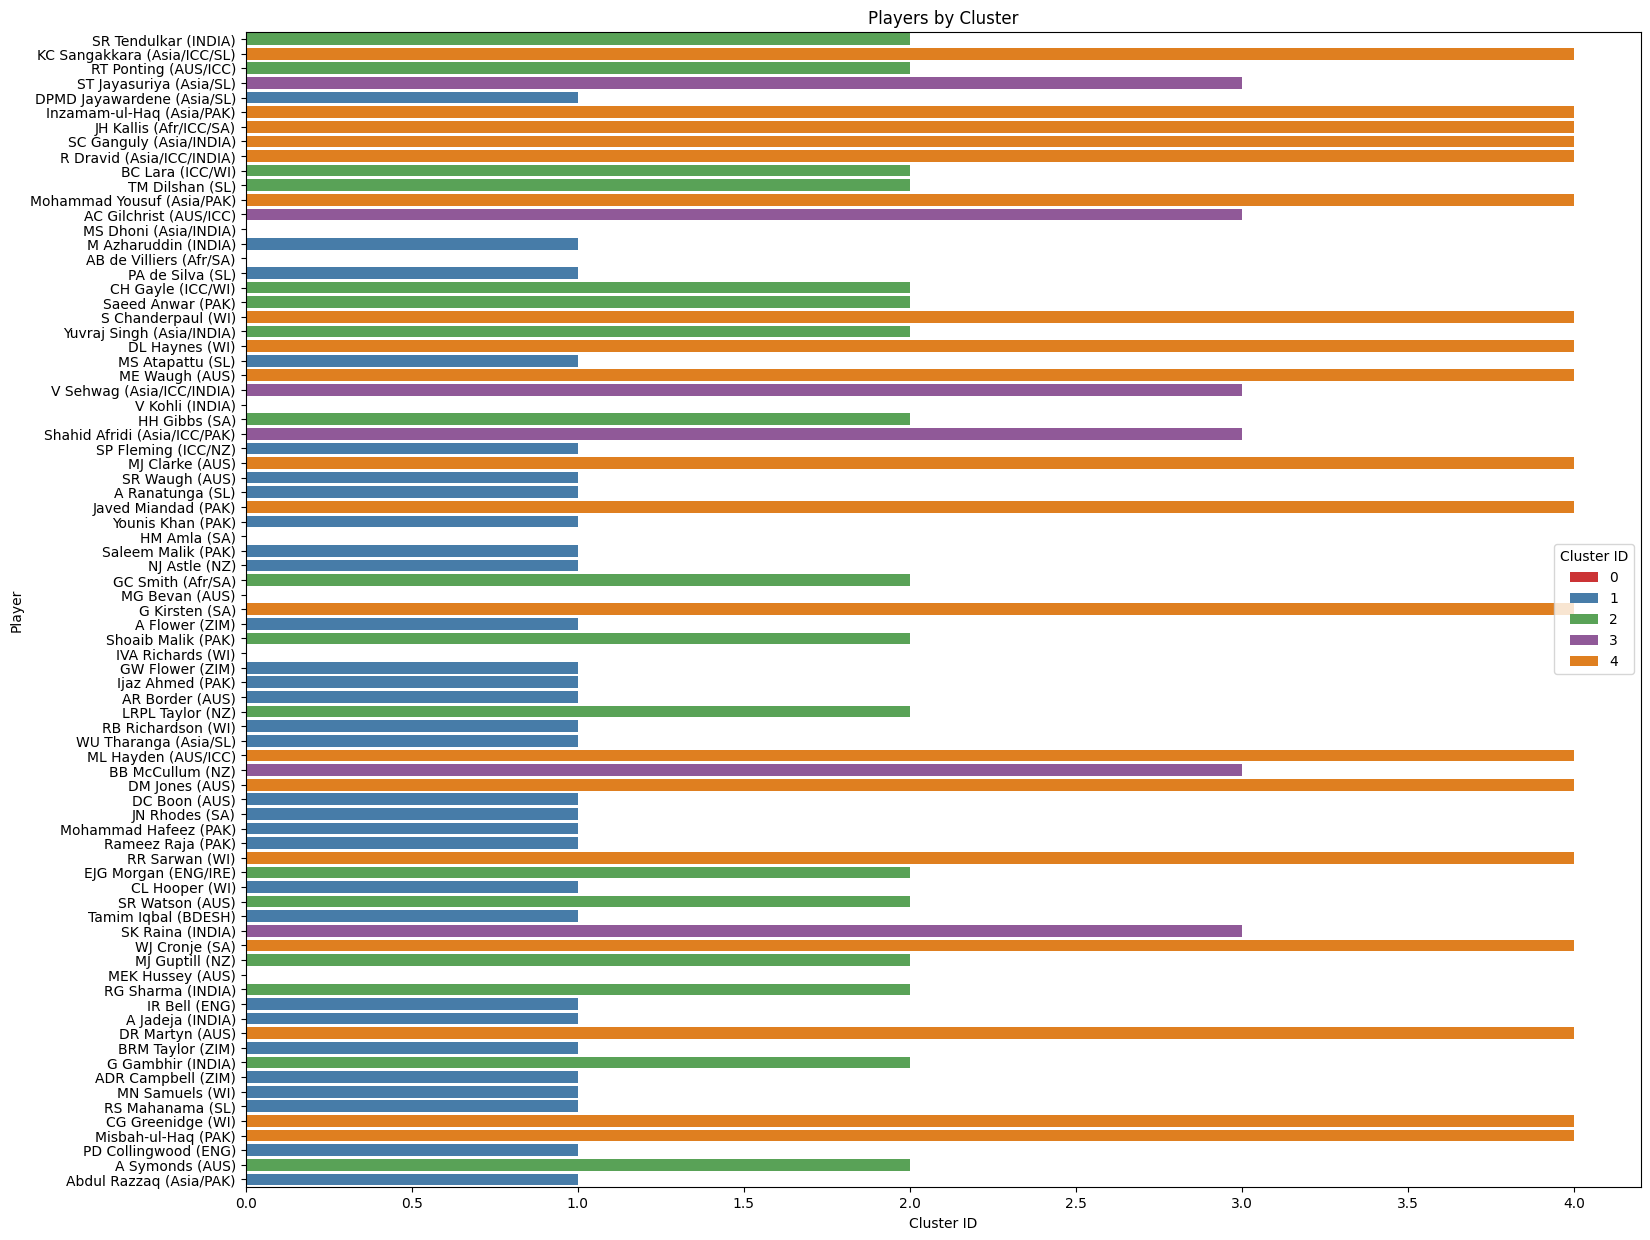

In [72]:
# Increase figure size (width, height in inches)
plt.figure(figsize=(18, 15))

# Bar plot with different colors per cluster_id
sns.barplot(
    x='cluster_id',
    y='Player',
    data=batsman_df_scaled,
    hue='cluster_id',
    palette='Set1'
)

plt.title('Players by Cluster')
plt.xlabel('Cluster ID')
plt.ylabel('Player')
plt.legend(title='Cluster ID')

plt.show()